In [1]:
import numpy as np 
import pandas as pd 



## Loading in the audio and video folders

In [2]:
import os
import librosa

audio_folder = "/Users/user/Downloads/dataset/audio_only"

audio_files = [f for f in os.listdir(audio_folder) if f.endswith(".wav")]

audio_data = {}

for file in audio_files:
    file_path = os.path.join(audio_folder, file)
    
    y, sr = librosa.load(file_path, sr=None)  
    
    audio_data[file] = {"waveform": y, "sampling_rate": sr}

print(f"Loaded {len(audio_data)} audio files.")


Loaded 45 audio files.


In [3]:
audio_data['audio_only_ID_9.wav']

{'waveform': array([ 0.        ,  0.06509399,  0.12857056, ..., -0.14590454,
        -0.0993042 , -0.05029297], dtype=float32),
 'sampling_rate': 16000}

In [4]:
ar = audio_data['audio_only_ID_39.wav']['waveform']
print(ar)
ar.shape

[ 0.          0.04199219  0.08300781 ... -0.02493286 -0.01696777
 -0.00860596]


(320000,)

In [5]:
video_folder = "/Users/user/Downloads/dataset/video_only"

video_files = [f for f in os.listdir(video_folder) if f.endswith(".mp4")]

print(f"Found {len(video_files)} video files:")
for file in video_files[:5]:  # Show first 5 files
    print(f"🎥 {file}")


Found 45 video files:
🎥 video_only_ID_22.mp4
🎥 video_only_ID_36.mp4
🎥 video_only_ID_5.mp4
🎥 video_only_ID_4.mp4
🎥 video_only_ID_37.mp4


In [6]:
import cv2
from IPython.display import Video

sample_video = video_files[0]
video_path = os.path.join(video_folder, sample_video)

Video(video_path, embed=True)


In [7]:
def detect_blue_ball(frame):
    """
    Detects a blue ball in a given frame and returns (cx, cy, radius).
    Returns None if no ball is found.
    """
    # Convert from BGR (OpenCV default) to HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    lower_blue = np.array([100, 150, 0])   
    upper_blue = np.array([140, 255, 255])
    
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.erode(mask, kernel, iterations=1)
    mask = cv2.dilate(mask, kernel, iterations=1)
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    
    c = max(contours, key=cv2.contourArea)
    (cx, cy), radius = cv2.minEnclosingCircle(c)
    return int(cx), int(cy), int(radius)


In [8]:
video_files[0]

'video_only_ID_22.mp4'

In [9]:
from tqdm import tqdm

def extract_ball_positions(video_path, desired_fps=30):
    """
    Processes the video on the fly to extract ball positions (x, y) for each frame
    at the specified frame rate, using color-based detection for a blue ball.
    Each returned tuple is (time, x, y, filename).

    Parameters:
        video_path (str): Path to the video file.
        desired_fps (int): Frame rate at which to sample the video.
    
    Returns:
        positions (list of tuples): Each tuple is (time, x, y, filename).
    """
    positions = []
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Cannot open video file {video_path}.")
        return positions

    file_name = os.path.basename(video_path)
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    frame_skip = int(round(original_fps / desired_fps))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_count = 0
    sampled_frame_index = 0

    pbar = tqdm(total=total_frames, desc="Processing frames", unit="frame")

    while True:
        ret, frame = cap.read()
        if not ret:
            break  
        
        pbar.update(1)
        
        if frame_count % frame_skip == 0:
            result = detect_blue_ball(frame)  
            time_sec = sampled_frame_index / desired_fps

            if result is not None:
                cx, cy, radius = result
                if radius > 2:
                    positions.append((time_sec, cx, cy, file_name))
                else:
                    positions.append((time_sec, None, None, file_name))
            else:
                positions.append((time_sec, None, None, file_name))

            sampled_frame_index += 1
        
        frame_count += 1

    pbar.close()
    cap.release()
    cv2.destroyAllWindows()
    return positions



In [10]:
ball_pos = []
for vid in video_files:
    video_path = f"{video_folder}/{vid}"
    print(f"Processing file: {vid}")
    ball_positions = extract_ball_positions(video_path, desired_fps=60)
    ball_pos.append(ball_positions)

# Print out the first 10 extracted positions from the first video.
for pos in ball_pos[0][:10]:
    print(pos)

Processing file: video_only_ID_22.mp4


Processing frames: 100%|███████████████| 1200/1200 [00:00<00:00, 2616.11frame/s]


Processing file: video_only_ID_36.mp4


Processing frames: 100%|███████████████| 1200/1200 [00:00<00:00, 2545.64frame/s]


Processing file: video_only_ID_5.mp4


...

Processing file: video_only_ID_8.mp4


Processing frames: 100%|███████████████| 1200/1200 [00:00<00:00, 2601.89frame/s]


Processing file: video_only_ID_13.mp4


Processing frames: 100%|███████████████| 1200/1200 [00:00<00:00, 2581.27frame/s]

(0.0, 220, 143, 'video_only_ID_22.mp4')
(0.016666666666666666, 226, 142, 'video_only_ID_22.mp4')
(0.03333333333333333, 232, 142, 'video_only_ID_22.mp4')
(0.05, 238, 140, 'video_only_ID_22.mp4')
(0.06666666666666667, 242, 140, 'video_only_ID_22.mp4')
(0.08333333333333333, 248, 138, 'video_only_ID_22.mp4')
(0.1, 254, 138, 'video_only_ID_22.mp4')
(0.11666666666666667, 258, 138, 'video_only_ID_22.mp4')
(0.13333333333333333, 264, 138, 'video_only_ID_22.mp4')
(0.15, 270, 138, 'video_only_ID_22.mp4')


In [11]:
for pos in ball_pos[0][:30]:
    print(pos)

(0.0, 220, 143, 'video_only_ID_22.mp4')
(0.016666666666666666, 226, 142, 'video_only_ID_22.mp4')
(0.03333333333333333, 232, 142, 'video_only_ID_22.mp4')
(0.05, 238, 140, 'video_only_ID_22.mp4')
(0.06666666666666667, 242, 140, 'video_only_ID_22.mp4')
(0.08333333333333333, 248, 138, 'video_only_ID_22.mp4')
(0.1, 254, 138, 'video_only_ID_22.mp4')
(0.11666666666666667, 258, 138, 'video_only_ID_22.mp4')
(0.13333333333333333, 264, 138, 'video_only_ID_22.mp4')
(0.15, 270, 138, 'video_only_ID_22.mp4')
(0.16666666666666666, 274, 137, 'video_only_ID_22.mp4')
(0.18333333333333332, 280, 137, 'video_only_ID_22.mp4')
(0.2, 286, 137, 'video_only_ID_22.mp4')
(0.21666666666666667, 290, 136, 'video_only_ID_22.mp4')
(0.23333333333333334, 296, 136, 'video_only_ID_22.mp4')
(0.25, 302, 136, 'video_only_ID_22.mp4')
(0.26666666666666666, 308, 136, 'video_only_ID_22.mp4')
(0.2833333333333333, 312, 136, 'video_only_ID_22.mp4')
(0.3, 318, 136, 'video_only_ID_22.mp4')
(0.31666666666666665, 324, 137, 'video_only_I

In [12]:
def compute_velocities(positions):
    """
    Given a list of positions (time, x, y), compute the per-frame velocities.
    
    The velocity at index i is computed as:
        vx = x[i] - x[i-1]
        vy = y[i] - y[i-1]
    
    If either the current or previous x or y is None, the velocity is set to (None, None).
    The velocity at the first timestamp is set to (0, 0).
    
    Returns a list of tuples: (time, vx, vy).
    """
    velocities = []
    file_name = positions[0][3]
    # First timestamp: velocity = (0, 0)
    t0, x0, y0 = positions[0][0], positions[0][1], positions[0][2]
    velocities.append((t0, 0, 0, file_name))
    
    # Compute velocity for subsequent timestamps
    for i in range(1, len(positions)):
        t, x, y = positions[i][0], positions[i][1], positions[i][2]
        prev_t, prev_x, prev_y = positions[i-1][0], positions[i-1][1], positions[i-1][2]
        
        # If current or previous position is missing, set velocity to (None, None)
        if x is None or prev_x is None or y is None or prev_y is None:
            velocities.append((t, None, None, file_name))
        else:
            vx = x - prev_x
            vy = y - prev_y
            velocities.append((t, vx, vy, file_name))
    
    return velocities

In [13]:
ball_velocities = []
for ball_positions in ball_pos:
    velocities = compute_velocities(ball_positions)
    ball_velocities.append(velocities)


## First solution(not optimal)- finding 13 MFCC coefficients for each file, then applying PCA on them to get (1200, 4) matrices for each audio file. From each video file, we create (1200, 4) matrices, (4 numbers for each frame- x coordinate, y coordinate, velocity in x direction, velocity in y direction). Then we compute similarity scores between each video audio pair to find the best matches

In [14]:
from sklearn.decomposition import PCA

def extract_and_reduce_mfcc(audio_path, sr=16000, desired_frames=1200, n_mfcc=13, target_dim=4):
    """
    Extracts MFCC features (n_mfcc=13 by default) and then reduces the dimensionality 
    to target_dim (default 4) using PCA, aligning with a video processed at 60 FPS.
    
    Parameters:
        audio_path (str): Path to the audio file.
        sr (int): Sampling rate (default 16,000 Hz).
        desired_frames (int): Number of MFCC frames (default 1200).
        n_mfcc (int): Number of MFCC coefficients (default 13).
        target_dim (int): Target number of dimensions after PCA (default 4).
    
    Returns:
        reduced_mfcc (np.ndarray): A 2D array of shape (target_dim, desired_frames).
    """
    y, sr = librosa.load(audio_path, sr=sr)
    hop_length = int(sr / 60)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=512, hop_length=hop_length)
    
    # Trim or pad to desired_frames
    T = mfcc.shape[1]
    if T > desired_frames:
        mfcc = mfcc[:, :desired_frames]
    elif T < desired_frames:
        mfcc = librosa.util.fix_length(mfcc, size=desired_frames, axis=1)
    
    pca = PCA(n_components=target_dim)
    reduced = pca.fit_transform(mfcc.T)  
    
    reduced_mfcc = reduced
    return reduced_mfcc




In [15]:
mfccs = {}
for file in audio_files:
    audio_path = f"/Users/user/Downloads/dataset/audio_only/{file}"  
    mfcc_features = extract_and_reduce_mfcc(audio_path, sr=16000, desired_frames=1200, n_mfcc=13, target_dim=4)
    mfccs[file] = mfcc_features

In [16]:
mfccs['audio_only_ID_9.wav'].shape

(1200, 4)

In [17]:
mfccs['audio_only_ID_9.wav']

array([[ 2.9110098e+02, -9.6100266e+01, -3.3620512e-01,  1.5916481e+01],
       [-1.4971924e+01, -2.2349159e+01,  8.1940231e+00,  2.5771866e+00],
       [-1.4925067e+01, -2.2747797e+01,  8.4254150e+00,  2.5165980e+00],
       ...,
       [-2.0521725e+01, -1.1299741e+01,  4.0192022e+00, -5.1600456e-01],
       [-1.8729443e+01, -1.2695071e+01,  3.8389809e+00,  1.0135827e+00],
       [-1.9865528e+01, -1.1928920e+01,  4.0153298e+00,  3.1801122e-03]],
      dtype=float32)

In [18]:
ball_pos[0][:30]

[(0.0, 220, 143, 'video_only_ID_22.mp4'),
 (0.016666666666666666, 226, 142, 'video_only_ID_22.mp4'),
 (0.03333333333333333, 232, 142, 'video_only_ID_22.mp4'),
 (0.05, 238, 140, 'video_only_ID_22.mp4'),
 (0.06666666666666667, 242, 140, 'video_only_ID_22.mp4'),
 (0.08333333333333333, 248, 138, 'video_only_ID_22.mp4'),
 (0.1, 254, 138, 'video_only_ID_22.mp4'),
 (0.11666666666666667, 258, 138, 'video_only_ID_22.mp4'),
 (0.13333333333333333, 264, 138, 'video_only_ID_22.mp4'),
 (0.15, 270, 138, 'video_only_ID_22.mp4'),
 (0.16666666666666666, 274, 137, 'video_only_ID_22.mp4'),
 (0.18333333333333332, 280, 137, 'video_only_ID_22.mp4'),
 (0.2, 286, 137, 'video_only_ID_22.mp4'),
 (0.21666666666666667, 290, 136, 'video_only_ID_22.mp4'),
 (0.23333333333333334, 296, 136, 'video_only_ID_22.mp4'),
 (0.25, 302, 136, 'video_only_ID_22.mp4'),
 (0.26666666666666666, 308, 136, 'video_only_ID_22.mp4'),
 (0.2833333333333333, 312, 136, 'video_only_ID_22.mp4'),
 (0.3, 318, 136, 'video_only_ID_22.mp4'),
 (0.316

In [19]:
ball_velocities[0][:30]

[(0.0, 0, 0, 'video_only_ID_22.mp4'),
 (0.016666666666666666, 6, -1, 'video_only_ID_22.mp4'),
 (0.03333333333333333, 6, 0, 'video_only_ID_22.mp4'),
 (0.05, 6, -2, 'video_only_ID_22.mp4'),
 (0.06666666666666667, 4, 0, 'video_only_ID_22.mp4'),
 (0.08333333333333333, 6, -2, 'video_only_ID_22.mp4'),
 (0.1, 6, 0, 'video_only_ID_22.mp4'),
 (0.11666666666666667, 4, 0, 'video_only_ID_22.mp4'),
 (0.13333333333333333, 6, 0, 'video_only_ID_22.mp4'),
 (0.15, 6, 0, 'video_only_ID_22.mp4'),
 (0.16666666666666666, 4, -1, 'video_only_ID_22.mp4'),
 (0.18333333333333332, 6, 0, 'video_only_ID_22.mp4'),
 (0.2, 6, 0, 'video_only_ID_22.mp4'),
 (0.21666666666666667, 4, -1, 'video_only_ID_22.mp4'),
 (0.23333333333333334, 6, 0, 'video_only_ID_22.mp4'),
 (0.25, 6, 0, 'video_only_ID_22.mp4'),
 (0.26666666666666666, 6, 0, 'video_only_ID_22.mp4'),
 (0.2833333333333333, 4, 0, 'video_only_ID_22.mp4'),
 (0.3, 6, 0, 'video_only_ID_22.mp4'),
 (0.31666666666666665, 6, 1, 'video_only_ID_22.mp4'),
 (0.3333333333333333, 5,

### Merging the position and velocity vectors for each frame for each video

In [20]:
def merge_positions_velocities(positions, velocities):
    """
    Merges position and velocity tuples for each frame.
    
    positions: list of (time, x, y, filename)
    velocities: list of (time, vx, vy, filename)
    
    Returns a list of (time, x, y, vx, vy, filename).
    """
    merged = []
    for (t_p, x, y, f_p), (t_v, vx, vy, f_v) in zip(positions, velocities):
        if t_p != t_v:
            print(f"Warning: Time mismatch {t_p} vs {t_v}")
        if f_p != f_v:
            print(f"Warning: Filename mismatch {f_p} vs {f_v}")
        
        merged.append((t_p, x, y, vx, vy, f_p))
    return merged



In [21]:
merged_data = []
for i in range(45):
    merged_data.append(merge_positions_velocities(ball_pos[i], ball_velocities[i]))


In [22]:
merged_data[0][:5]

[(0.0, 220, 143, 0, 0, 'video_only_ID_22.mp4'),
 (0.016666666666666666, 226, 142, 6, -1, 'video_only_ID_22.mp4'),
 (0.03333333333333333, 232, 142, 6, 0, 'video_only_ID_22.mp4'),
 (0.05, 238, 140, 6, -2, 'video_only_ID_22.mp4'),
 (0.06666666666666667, 242, 140, 4, 0, 'video_only_ID_22.mp4')]

In [23]:
from collections import defaultdict

def build_feature_dict(merged_data):
    """
    Builds a dictionary:
        {
          filename: np.array of shape (4, N),
          ...
        }
    from a list of tuples (time, x, y, vx, vy, filename).
    Each array is transposed so that the first dimension represents the 4 features,
    and the second dimension represents the number of frames (N).
    """
    data_dict = defaultdict(list)
    
    for (t, x, y, vx, vy, fname) in merged_data:
        data_dict[fname].append([x, y, vx, vy])
    
    data_dict = dict(data_dict)
    
    for fname, frame_list in data_dict.items():
        arr = np.array(frame_list, dtype=np.float32)
        data_dict[fname] = arr
    
    return data_dict


In [24]:
merged_data[0][:5]

[(0.0, 220, 143, 0, 0, 'video_only_ID_22.mp4'),
 (0.016666666666666666, 226, 142, 6, -1, 'video_only_ID_22.mp4'),
 (0.03333333333333333, 232, 142, 6, 0, 'video_only_ID_22.mp4'),
 (0.05, 238, 140, 6, -2, 'video_only_ID_22.mp4'),
 (0.06666666666666667, 242, 140, 4, 0, 'video_only_ID_22.mp4')]

In [25]:
all_merged_tuples = []
for video_list in merged_data:
    all_merged_tuples.extend(video_list)

feature_dict = build_feature_dict(all_merged_tuples)


In [26]:
feature_dict['video_only_ID_32.mp4'][:30]

array([[220., 143.,   0.,   0.],
       [226., 138.,   6.,  -5.],
       [230., 133.,   4.,  -5.],
       [234., 129.,   4.,  -4.],
       [238., 124.,   4.,  -5.],
       [244., 119.,   6.,  -5.],
       [248., 114.,   4.,  -5.],
       [252., 110.,   4.,  -4.],
       [256., 105.,   4.,  -5.],
       [262., 101.,   6.,  -4.],
       [266.,  96.,   4.,  -5.],
       [270.,  92.,   4.,  -4.],
       [274.,  88.,   4.,  -4.],
       [278.,  82.,   4.,  -6.],
       [284.,  78.,   6.,  -4.],
       [288.,  74.,   4.,  -4.],
       [292.,  70.,   4.,  -4.],
       [296.,  66.,   4.,  -4.],
       [302.,  62.,   6.,  -4.],
       [306.,  58.,   4.,  -4.],
       [310.,  54.,   4.,  -4.],
       [314.,  52.,   4.,  -2.],
       [320.,  48.,   6.,  -4.],
       [324.,  44.,   4.,  -4.],
       [328.,  41.,   4.,  -3.],
       [332.,  37.,   4.,  -4.],
       [ nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan]], dtype=flo

### Note: nan indicates where the ball was outside the frame

In [27]:
feature_dict['video_only_ID_32.mp4'].shape

(1200, 4)

In [28]:
mfccs['audio_only_ID_9.wav'].shape

(1200, 4)

In [29]:
def compute_similarity_ignore_missing(v_features, a_features, metric='euclidean', penalty=100):
    """
    Computes a similarity score between two arrays of shape (1200, 4),
    handling missing frames (represented as np.nan) by skipping them and
    adding a penalty for each missing frame.
    
    Parameters:
        v_features (np.ndarray): Video features, shape (1200, 4)
        a_features (np.ndarray): Audio features, shape (1200, 4)
        metric (str): 'euclidean' or 'cosine'
        penalty (float): Penalty to add per missing frame (as a fraction of total frames)
        
    Returns:
        score (float): Overall similarity score.
    """
    distances = []
    missing_count = 0
    total_frames = v_features.shape[0]
    
    for v_vec, a_vec in zip(v_features, a_features):
        # Check if the video vector has any missing values (assumed to be np.nan)
        if np.isnan(v_vec).any():
            missing_count += 1
            continue  
        if metric == 'euclidean':
            d = np.linalg.norm(v_vec - a_vec)
        elif metric == 'cosine':
            norm_v = np.linalg.norm(v_vec)
            norm_a = np.linalg.norm(a_vec)
            if norm_v == 0 or norm_a == 0:
                d = 1  
            else:
                cos_sim = np.dot(v_vec, a_vec) / (norm_v * norm_a)
                d = 1 - cos_sim
        else:
            raise ValueError("Unsupported metric. Choose 'euclidean' or 'cosine'.")
        distances.append(d)
    
    if len(distances) > 0:
        avg_distance = np.mean(distances)
    else:
        avg_distance = 0  # or you could set it to np.nan

    total_score = avg_distance + penalty * (missing_count / total_frames)
    return total_score

def compute_all_similarity(dict_video, dict_audio, metric='euclidean', penalty=100):
    """
    Computes similarity scores between every video file and every audio file,
    handling missing (out-of-frame) data in the video features.
    
    Parameters:
        dict_video (dict): Dictionary mapping video filenames to features,
                           each of shape (1200, 4) (with missing values as np.nan).
        dict_audio (dict): Dictionary mapping audio filenames to features,
                           each of shape (1200, 4).
        metric (str): 'euclidean' (default) or 'cosine'
        penalty (float): Penalty added for each missing frame (as a fraction of total frames)
    
    Returns:
        sim_matrix (dict): Nested dictionary, where sim_matrix[video][audio] is the similarity score.
    """
    sim_matrix = {}
    for vname, v_features in dict_video.items():
        sim_matrix[vname] = {}
        for aname, a_features in dict_audio.items():
            if v_features.shape != a_features.shape:
                print(f"Warning: Shape mismatch for {vname} and {aname}: {v_features.shape} vs {a_features.shape}")
                continue
            score = compute_similarity_ignore_missing(v_features, a_features, metric=metric, penalty=penalty)
            sim_matrix[vname][aname] = score
    return sim_matrix



In [30]:
def normalize_feature_dict(feature_dict, method='zscore'):
    """
    Normalizes each NumPy array in the dictionary.
    
    Parameters:
        feature_dict (dict): Dictionary mapping filenames to NumPy arrays of shape (1200, 4).
        method (str): Normalization method. Options:
                      - 'zscore': subtract mean and divide by std for each feature.
                      - 'minmax': scale each feature to [0, 1].
                      
    Returns:
        norm_dict (dict): Dictionary with the same keys, where each value is a normalized array.
    """
    norm_dict = {}
    
    for fname, features in feature_dict.items():
        if method == 'zscore':
            mean = np.nanmean(features, axis=0)
            std = np.nanstd(features, axis=0)
            std[std == 0] = 1
            norm_features = (features - mean) / std
        elif method == 'minmax':
            min_val = np.nanmin(features, axis=0)
            max_val = np.nanmax(features, axis=0)
            range_val = max_val - min_val
            range_val[range_val == 0] = 1
            norm_features = (features - min_val) / range_val
        else:
            raise ValueError("Unsupported normalization method. Choose 'zscore' or 'minmax'.")
            
        norm_dict[fname] = norm_features
        
    return norm_dict



In [31]:
norm_feature_dict = normalize_feature_dict(feature_dict, method='zscore')


In [32]:
norm_feature_dict['video_only_ID_32.mp4'][0]

array([ 0.01829568,  0.22197686,  0.0229168 , -0.03465382], dtype=float32)

In [33]:
mfccs['audio_only_ID_32.wav'][0]

array([271.55212 , -88.56564 ,  34.59729 ,  16.363611], dtype=float32)

In [34]:
norm_mfcc = normalize_feature_dict(mfccs, method='zscore')

In [35]:
norm_mfcc['audio_only_ID_32.wav'][0]

array([ 2.5204976, -3.1664493,  1.9201083,  1.9946831], dtype=float32)

In [36]:
similarity_matrix = compute_all_similarity(norm_feature_dict, norm_mfcc, metric='cosine')

In [37]:
def find_top_match(sim_matrix):
    results = {}
    for vname, audio_scores in sim_matrix.items():
        sorted_audio = sorted(audio_scores.items(), key=lambda x: x[1])
        top_1 = sorted_audio[:1]
        results[vname] = top_1
    return results



In [38]:
top_dict = find_top_match(similarity_matrix)

for video, matches in top_dict.items():
     print(f"\nVideo: {video}")
     for audio, score in matches:
         print(f"  {audio} -> Score: {score:.4f}")


Video: video_only_ID_22.mp4
  audio_only_ID_23.wav -> Score: 5.4338

Video: video_only_ID_36.mp4
  audio_only_ID_23.wav -> Score: 3.7016

Video: video_only_ID_5.mp4
  audio_only_ID_12.wav -> Score: 5.7347

Video: video_only_ID_4.mp4
  audio_only_ID_18.wav -> Score: 2.9428

Video: video_only_ID_37.mp4
  audio_only_ID_44.wav -> Score: 1.8727

Video: video_only_ID_23.mp4
  audio_only_ID_44.wav -> Score: 66.8816

Video: video_only_ID_35.mp4
  audio_only_ID_26.wav -> Score: 1.1373

Video: video_only_ID_21.mp4
  audio_only_ID_4.wav -> Score: 2.4827

Video: video_only_ID_6.mp4
  audio_only_ID_31.wav -> Score: 53.2264

Video: video_only_ID_7.mp4
  audio_only_ID_14.wav -> Score: 3.8261

Video: video_only_ID_20.mp4
  audio_only_ID_3.wav -> Score: 2.6675

Video: video_only_ID_34.mp4
  audio_only_ID_3.wav -> Score: 3.6445

Video: video_only_ID_18.mp4
  audio_only_ID_16.wav -> Score: 2.0149

Video: video_only_ID_30.mp4
  audio_only_ID_4.wav -> Score: 3.8668

Video: video_only_ID_24.mp4
  audio_onl

In [39]:
def count_unique_audio(top_dict):
    """
    Returns the number of unique audio filenames among the top match in the dictionary.
    
    top_dict: 
      video_filename -> list of (audio_filename, score)
    """
    unique_audio = set()
    for video, matches in top_dict.items():
        for audio, score in matches:
            unique_audio.add(audio)
    return len(unique_audio)

num_unique_audio = count_unique_audio(top_dict)
print(f"Number of unique audio files in the top match: {num_unique_audio}")


Number of unique audio files in the top match: 20


### Only 20 audio files are unique matches, so many videos have the same audio file as the top match, so not a good matching

## Now implementing a much better solution using collision onset calculation

In [40]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def detect_audio_collisions(audio_path, sr=16000, window_length=0.05, prominence=0.1):
    """
    Detects collision-like events in an audio file using peak detection on a smoothed amplitude envelope.
    
    Parameters:
        audio_path (str): Path to the audio file.
        sr (int): Sampling rate for loading the audio. Default is 16000 Hz.
        window_length (float): Length (in seconds) of the moving average window for smoothing.
        prominence (float): Required prominence of peaks for detection.
        
    Returns:
        peak_times (np.ndarray): Array of times (in seconds) where peaks are detected.
        envelope_smooth (np.ndarray): Smoothed amplitude envelope.
        y (np.ndarray): The audio time series.
        sr (int): Sampling rate.
    """
    y, sr = librosa.load(audio_path, sr=sr)
    
    # Compute the amplitude envelope (absolute value)
    envelope = np.abs(y)
    
    # Define window length in samples and smooth the envelope via a moving average
    window_samples = int(window_length * sr)
    if window_samples < 1:
        window_samples = 1
    envelope_smooth = np.convolve(envelope, np.ones(window_samples)/window_samples, mode='same')
    
    peaks, properties = find_peaks(envelope_smooth, prominence=prominence)
    
    peak_times = peaks / sr
    
    return peak_times, envelope_smooth, y, sr


Detected collision (peak) times (seconds):
[ 1.642125   2.758375   4.874      5.8416875  8.1078125  8.8916875
 11.342125  11.908375  13.37475   13.37525   14.5749375 14.8916875
 16.3421875 17.8085    19.2734375 19.2744375 19.274625  19.2750625]


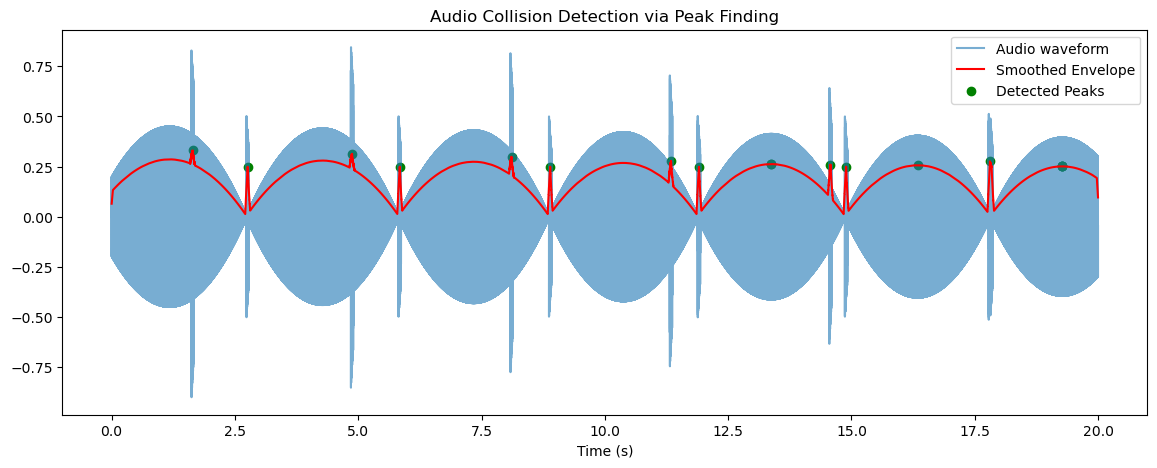

In [41]:
# Sample usage:
audio_path = f'{audio_folder}/audio_only_ID_1.wav'  
peak_times, envelope_smooth, y, sr = detect_audio_collisions(audio_path, sr=16000, window_length=0.05, prominence=0.1)

print("Detected collision (peak) times (seconds):")
print(peak_times)

# Plot for visualization:
times = np.arange(len(y)) / sr
plt.figure(figsize=(14, 5))
plt.plot(times, y, alpha=0.6, label='Audio waveform')
plt.plot(times, envelope_smooth, label='Smoothed Envelope', color='red')
plt.scatter(peak_times, envelope_smooth[(peak_times*sr).astype(int)], 
            color='green', marker='o', label='Detected Peaks')
plt.xlabel('Time (s)')
plt.title('Audio Collision Detection via Peak Finding')
plt.legend()
plt.show()


### Finding the collisions in the video file, based on if the ball is changing direction(using velocity to check the direction of the ball). If the last velocity is None, the last recorded velocity is taken

In [42]:
def count_collisions_by_angle(velocity_data, angle_threshold=np.pi/2, min_speed=0.1):
    """
    Counts collision events based on significant changes in the sign-based direction of velocity.
    
    Uses the last valid (non-None) velocity as the previous value when the immediate previous frame is missing.
    
    Parameters:
        velocity_data (list of tuples): Each tuple is (time, vx, vy, filename).
        angle_threshold (float): Threshold (in radians) for the change in direction to count as a collision.
                                   Default is np.pi/2 (i.e., 90 degrees).
        min_speed (float): Minimum speed below which frames are skipped (to avoid noise).
    
    Returns:
        collisions (list): A list of times where a collision (direction change) is detected.
    """
    collisions = []
    last_valid_velocity = None  
    last_valid_time = None
    
    for (t, vx, vy, fn) in velocity_data:
        if vx is None or vy is None:
            continue
        
        speed_curr = np.sqrt(vx**2 + vy**2)
        if speed_curr < min_speed:
            continue
        
        if last_valid_velocity is None:
            last_valid_velocity = (vx, vy)
            last_valid_time = t
            continue
        
        vx_prev, vy_prev = last_valid_velocity
        speed_prev = np.sqrt(vx_prev**2 + vy_prev**2)
        if speed_prev < min_speed:
            last_valid_velocity = (vx, vy)
            last_valid_time = t
            continue
        
        sign_vx_prev = np.sign(vx_prev)
        sign_vy_prev = np.sign(vy_prev)
        sign_vx_curr = np.sign(vx)
        sign_vy_curr = np.sign(vy)
        
        angle_prev = np.arctan2(sign_vy_prev, sign_vx_prev)
        angle_curr = np.arctan2(sign_vy_curr, sign_vx_curr)
        
        delta_angle = np.abs(np.angle(np.exp(1j * (angle_curr - angle_prev))))
        
        if delta_angle >= angle_threshold:
            collisions.append(t)
        
        last_valid_velocity = (vx, vy)
        last_valid_time = t
    
    return collisions


In [43]:
ball_velocities[0][:10]

[(0.0, 0, 0, 'video_only_ID_22.mp4'),
 (0.016666666666666666, 6, -1, 'video_only_ID_22.mp4'),
 (0.03333333333333333, 6, 0, 'video_only_ID_22.mp4'),
 (0.05, 6, -2, 'video_only_ID_22.mp4'),
 (0.06666666666666667, 4, 0, 'video_only_ID_22.mp4'),
 (0.08333333333333333, 6, -2, 'video_only_ID_22.mp4'),
 (0.1, 6, 0, 'video_only_ID_22.mp4'),
 (0.11666666666666667, 4, 0, 'video_only_ID_22.mp4'),
 (0.13333333333333333, 6, 0, 'video_only_ID_22.mp4'),
 (0.15, 6, 0, 'video_only_ID_22.mp4')]

In [44]:
def map_onsets_to_frames(onset_times, fps=60):
    """
    Maps each onset time (in seconds) to the nearest frame index for a given fps.
    
    Parameters:
        onset_times (array-like): List/array of onset times in seconds.
        fps (int): Frames per second (default=60).
        
    Returns:
        frame_indices (list of int): Mapped frame indices for each onset time.
    """
    frame_indices = [int(round(t * fps)) for t in onset_times]
    return frame_indices


In [45]:
def frames_to_collision_array(frame_indices, total_frames=1200):
    """
    Converts a list of collision (or onset) frame indices into a binary array 
    of shape (total_frames,).

    Parameters:
        frame_indices (list of int): The frames at which a collision (or onset) occurs.
        total_frames (int): The total number of frames in the video/audio timeline. 
                            Defaults to 1200 (for a 20s clip at 60 FPS).

    Returns:
        np.ndarray: A 1D array of length total_frames, where each element is 0 or 1.
                    1 indicates a collision (or onset) at that frame, 0 otherwise.
    """
    collision_array = np.zeros(total_frames, dtype=int)
    for f in frame_indices:
        if 0 <= f < total_frames:
            collision_array[f] = 1
    return collision_array


## Computing onset times based on audio, for each audio file and storing the timestamps as binary arrays- 1 indicating that there was a collision in that time frame, 0 indicating that there was no collision

In [46]:
onset_array_times = {}
for key in audio_data.keys():
    path = f"{audio_folder}/{key}"
    peak_times, envelope_smooth, y, sr = detect_audio_collisions(path, sr=16000, window_length=0.05, prominence=0.1)
    frame_indices = map_onsets_to_frames(peak_times, fps=60)
    oa = frames_to_collision_array(frame_indices)
    onset_array_times[key] = oa
    

In [47]:
len(onset_array_times.keys())

45

In [48]:
onset_array_times['audio_only_ID_1.wav'].shape

(1200,)

## Obtaining 1200 dimensional vector for each audio file(60 frames-corresponding to the video frames, 20 seconds so 60*20)

## Obtaining the collision times based on the ball's direction changing, again a binary array with 1200 numbers- 60 per second

In [49]:
collision_array_times = {}

i = 0
for ball_vel in ball_velocities:
    collisions = count_collisions_by_angle(ball_velocities[i])
    fn = ball_velocities[i][0][3]
    collision_frames = map_onsets_to_frames(collisions, fps=60)
    ca = frames_to_collision_array(collision_frames)
    collision_array_times[fn] = ca
    i = i + 1

In [50]:
collision_array_times['video_only_ID_32.mp4']

array([0, 0, 0, ..., 0, 0, 0])

In [51]:
collision_array_times['video_only_ID_32.mp4'].shape

(1200,)

# A Popular Set-Based Similarity Measure: Dice Coefficient

I will use a popular set-based similarity measure called the **Dice Coefficient**, which is closely related to the Jaccard similarity but gives slightly different weighting to overlaps. For **binary arrays**, the Dice coefficient $D$ between two sets $X$ and $Y$ is:

$$D(X,Y) = \frac{2 |X \cap Y|}{|X| + |Y|}$$

Where:
- $|X|$ is the number of 1s in $X$,
- $|Y|$ is the number of 1s in $Y$,
- $|X \cap Y|$ is the number of positions where both $X$ and $Y$ are 1.

In [52]:
def compute_all_dice_similarity(dict_video, dict_audio):
    """
    Computes the Dice similarity between all video and audio pairs.

    Dice(X, Y) = 2 * |X ∩ Y| / (|X| + |Y|)
    for binary arrays X, Y.

    Parameters:
        dict_video (dict): Maps video filenames to binary arrays (shape (1200,)).
        dict_audio (dict): Maps audio filenames to binary arrays (shape (1200,)).

    Returns:
        sim_matrix (dict): Nested dict:
            sim_matrix[video_filename][audio_filename] = Dice similarity
    """
    sim_matrix = {}
    
    for vname, video_array in dict_video.items():
        sim_matrix[vname] = {}
        for aname, audio_array in dict_audio.items():
            if video_array.shape != audio_array.shape:
                print(f"Warning: Shape mismatch for {vname} and {aname}: {video_array.shape} vs {audio_array.shape}")
                continue
            
            # Count how many 1s in each array (|X| and |Y|)
            sum_v = np.sum(video_array)
            sum_a = np.sum(audio_array)
            
            # Count how many positions where both arrays are 1 (|X ∩ Y|)
            intersection = np.sum(np.logical_and(video_array, audio_array))
            
            denom = (sum_v + sum_a)
            if denom == 0:
                # If both are all zeros, define similarity as NaN or 0.0
                similarity = np.nan
            else:
                similarity = (2.0 * intersection) / denom
            
            sim_matrix[vname][aname] = similarity
    
    return sim_matrix


In [53]:
dice_sim_matrix = compute_all_dice_similarity(collision_array_times, onset_array_times)


In [54]:
def find_top_match1(sim_matrix):
    results = {}
    for vname, audio_scores in sim_matrix.items():
        sorted_audio = sorted(audio_scores.items(), key=lambda x: x[1], reverse=True)
        top_1 = sorted_audio[0]  # Get the highest similarity match.
        results[vname] = top_1
    return results


In [55]:
def count_unique_audio1(top_dict):
    """
    Returns the number of unique audio filenames among the top matches in the dictionary.
    
    Parameters:
        top_dict: A dictionary mapping video filenames to either:
                  - A single tuple (audio_filename, score), or 
                  - A list of (audio_filename, score) tuples.
    
    Returns:
        int: The number of unique audio filenames that appear as a top match.
    """
    unique_audio = set()
    for video, matches in top_dict.items():
        if isinstance(matches, list):
            for audio, score in matches:
                unique_audio.add(audio)
        elif isinstance(matches, tuple):
            unique_audio.add(matches[0])
    return len(unique_audio)


In [56]:
top_dict1 = find_top_match1(dice_sim_matrix)

In [57]:
num_unique_audio = count_unique_audio1(top_dict1)
print(f"Number of unique audio files in the top match: {num_unique_audio}")

Number of unique audio files in the top match: 43


## This is a lot better than the previous approach, where had only 20 unique matches

# The Hungarian Algorithm

The Hungarian algorithm is a method for solving assignment problems optimally. In short:

1. **Build a Cost Matrix:** Represent the cost of pairing each item in one set with each item in the other.

2. **Normalize the Matrix:** Subtract the minimum value from each row and then each column so that every row and column has at least one zero.

3. **Cover Zeros:** Find the minimum number of lines (rows/columns) that cover all zeros. If that number equals the matrix size, an optimal assignment is possible.

4. **Adjust the Matrix:** If not, subtract the smallest uncovered value from all uncovered elements and add it to elements covered twice. Repeat the covering step.

5. **Extract the Assignment:** Choose a zero from each row (and column) so that each item is paired uniquely, yielding an optimal one-to-one matching.

This process ensures that you achieve the best overall assignment while balancing all individual pairings.

In [58]:
from scipy.optimize import linear_sum_assignment

def hungarian_assignment(sim_matrix, nan_cost=1e6):
    """
    Uses the Hungarian algorithm to assign each video a unique audio track.
    
    Parameters:
        sim_matrix (dict): Nested dictionary where sim_matrix[video][audio] is the similarity score.
                           Assumes each video has the same set of audio keys.
        nan_cost (float): Cost to assign if a similarity is NaN.
        
    Returns:
        matching (dict): Dictionary mapping each video filename to a tuple (audio filename, similarity score).
    """
    video_names = list(sim_matrix.keys())
    audio_names = list(next(iter(sim_matrix.values())).keys())
    
    n = len(video_names)
    m = len(audio_names)
    
    
    cost_matrix = np.zeros((n, m))
    for i, vname in enumerate(video_names):
        for j, aname in enumerate(audio_names):
            sim = sim_matrix[vname].get(aname, np.nan)
            if np.isnan(sim):
                cost_matrix[i, j] = nan_cost
            else:
                cost_matrix[i, j] = -sim

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Build the matching dictionary: video -> (audio, similarity)
    matching = {}
    for i, j in zip(row_ind, col_ind):
        video = video_names[i]
        audio = audio_names[j]
        matching[video] = (audio, sim_matrix[video][audio])
    
    return matching

In [59]:
import re

def extract_video_id(filename):
    """
    Extracts the numeric ID from a filename like 'video_only_ID_32.mp4'.
    Returns an integer, or a large number if no ID is found.
    """
    match = re.search(r'\d+', filename)
    return int(match.group()) if match else float('inf')

def analyze_hungarian_matches_numeric(sim_matrix, dict_audio):
    """
    Computes a one-to-one matching between videos and audio tracks using the Hungarian algorithm,
    then prints results sorted by the numeric portion in the video filename.
    """
    matching = hungarian_assignment(sim_matrix)  
    
    # Count the frequency of each audio track being matched
    audio_counts = {}
    for v, (a, score) in matching.items():
        audio_counts[a] = audio_counts.get(a, 0) + 1
    
    # Sort video filenames by their numeric ID
    sorted_videos = sorted(matching.keys(), key=extract_video_id)
    
    print("Hungarian Matching (Video -> Audio) [Sorted by Numeric ID]:")
    for video in sorted_videos:
        audio, score = matching[video]
        print(f"  {video} -> {audio} (similarity: {score:.4f})")
    
    print("\nAudio tracks matched to at least one video:")
    for audio, count in audio_counts.items():
        print(f"  {audio}: matched for {count} video(s)")
    
    all_audio_files = set(dict_audio.keys())
    matched_audio_files = set(audio_counts.keys())
    unmatched_audios = all_audio_files - matched_audio_files
    print("\nAudio tracks that are not matched to any video:")
    for audio in sorted(unmatched_audios):
        print(f"  {audio}")
    
    return matching, audio_counts


In [60]:
matching, audio_counts = analyze_hungarian_matches_numeric(dice_sim_matrix, audio_data)


Hungarian Matching (Video -> Audio) [Sorted by Numeric ID]:
  video_only_ID_1.mp4 -> audio_only_ID_45.wav (similarity: 0.3556)
  video_only_ID_2.mp4 -> audio_only_ID_1.wav (similarity: 0.4286)
  video_only_ID_3.mp4 -> audio_only_ID_29.wav (similarity: 0.3256)
  video_only_ID_4.mp4 -> audio_only_ID_18.wav (similarity: 0.5106)
  video_only_ID_5.mp4 -> audio_only_ID_19.wav (similarity: 0.4828)
  video_only_ID_6.mp4 -> audio_only_ID_31.wav (similarity: 0.5000)
  video_only_ID_7.mp4 -> audio_only_ID_14.wav (similarity: 0.6122)
  video_only_ID_8.mp4 -> audio_only_ID_38.wav (similarity: 0.2778)
  video_only_ID_9.mp4 -> audio_only_ID_44.wav (similarity: 0.2376)
  video_only_ID_10.mp4 -> audio_only_ID_23.wav (similarity: 0.2821)
  video_only_ID_11.mp4 -> audio_only_ID_20.wav (similarity: 0.3692)
  video_only_ID_12.mp4 -> audio_only_ID_24.wav (similarity: 0.2222)
  video_only_ID_13.mp4 -> audio_only_ID_6.wav (similarity: 0.1345)
  video_only_ID_14.mp4 -> audio_only_ID_13.wav (similarity: 0.3438)

## Converting the matching to a csv file


In [61]:
import csv
def extract_video_id(filename):
    """
    Extracts the numeric ID from a filename like 'video_only_ID_32.mp4'.
    Returns an integer, or a large number if no ID is found.
    """
    match = re.search(r'\d+', filename)
    return int(match.group()) if match else float('inf')

def export_matching_to_csv(matching, csv_path, sort_numeric=False):
    """
    Exports the Hungarian matching results to a CSV file.
    
    Parameters:
        matching (dict): Dictionary of the form:
                         matching[video_filename] = (audio_filename, similarity)
        csv_path (str): Path to the output CSV file.
        sort_numeric (bool): If True, sort video filenames by their numeric ID 
                             (e.g., 'video_only_ID_32.mp4' -> 32).
                             Otherwise, sort alphabetically.
    """
    video_filenames = list(matching.keys())
    if sort_numeric:
        video_filenames.sort(key=extract_video_id)
    else:
        video_filenames.sort()  

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["VIDEO", "AUDIO"])
        
        for video in video_filenames:
            audio, score = matching[video]
            writer.writerow([video, audio])

csv_file_path = "/Users/user/Downloads/solution_220150019.csv"
export_matching_to_csv(matching, csv_file_path, sort_numeric=True)
print(f"CSV exported to {csv_file_path}")


CSV exported to /Users/user/Downloads/solution_220150019.csv
